# Phase 2R：Chen2020 模型与控制状态充分性审计

本 notebook 只读取已冻结的审计产物，不重新运行 DFN、MPC 或 ANN 训练。

**结论：**固定参数 2RC+双节点热模型通过本轮预设筛查，但尚不能证明全运行域充分；SOC/温度相关电热耦合模型未通过；当前五状态 DNN 输入下的教师控制律未达到局部单值性门槛。暂不训练新 ANN。

## 1. 加载冻结产物

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "outputs" / "phase2r_sufficiency_audit").exists():
    ROOT = ROOT.parent
OUT = ROOT / "outputs" / "phase2r_sufficiency_audit"
metrics = json.loads((OUT / "metrics.json").read_text(encoding="utf-8"))
horizon = pd.read_csv(OUT / "model_horizon_metrics.csv")
thermal = pd.read_csv(OUT / "thermal_structure_metrics.csv")
state = pd.read_csv(OUT / "state_conditional_variance_metrics.csv")
availability = pd.read_csv(OUT / "candidate_variable_availability.csv")
print(f"结果目录：{OUT.resolve()}")
print(metrics["decision"])

结果目录：C:\Users\LENOVO\Documents\动力电池AI\outputs\phase2r_sufficiency_audit
{'fixed_model_sufficient': True, 'related_model_sufficient': False, 'current_dnn_state_sufficient': False, 'next_action': '先在新教师数据中精确记录并验证上一最优序列摘要等控制记忆，再决定 Chen2020 DNN 的扩充输入；暂不训练新 ANN。'}


## 2. 2R-A 审计合同

- 初始 SOC：60%、65%、70%、75%、80%；其中 60/70/80% 为参数锚点，65/75% 为 SOC 插值留出。
- 温度：15/25/30 ℃；脉冲：0.5/1/2 C，持续 300 s。
- 预测时域：5/25/300 s。
- 物理约束分类边界：4.2 V、35 ℃。
- 比较固定参数/相关参数 2RC，以及单温度/双节点热结构。

In [2]:
holdout = pd.DataFrame(metrics["model_audit"]["holdout_summary"])
display(holdout.style.format({
    "voltage_rmse_mv_mean": "{:.2f}", "voltage_rmse_mv_max": "{:.2f}",
    "temperature_rmse_c_mean": "{:.3f}", "temperature_rmse_c_max": "{:.3f}"
}))
assert metrics["model_audit"]["pulse_profile_count"] == 45

,variant,horizon_s,voltage_rmse_mv_mean,voltage_rmse_mv_max,temperature_rmse_c_mean,temperature_rmse_c_max,voltage_false_safe_count,temperature_false_safe_count
0,fixed_2rc_dual,5.000000,18.33,38.99,0.027,0.067,0,0
1,fixed_2rc_dual,25.000000,18.49,38.20,0.099,0.248,0,0
2,fixed_2rc_dual,300.000000,28.72,51.82,0.511,1.409,0,0
3,related_2rc_dual,5.000000,18.61,35.06,0.007,0.015,0,0
4,related_2rc_dual,25.000000,20.41,33.28,0.047,0.138,0,0
5,related_2rc_dual,300.000000,29.68,60.57,1.589,4.901,3,0
6,related_2rc_single,5.000000,18.61,35.06,0.007,0.015,0,0
7,related_2rc_single,25.000000,20.41,33.28,0.046,0.130,0,0
8,related_2rc_single,300.000000,29.68,60.57,1.564,4.834,3,0


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32516\329693020.py:10: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32516\329693020.py:10: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32516\329693020.py:10: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32516\329693020.py:10: UserWarning: Glyph 22495 (\N{CJK UNIFIED IDEOGRAPH-57DF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32516\329693020.py:10: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\LENOVO\AppData\Local\Temp\

C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21387 (\N{CJK UNIFIED IDEOGRAPH-538B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtoo

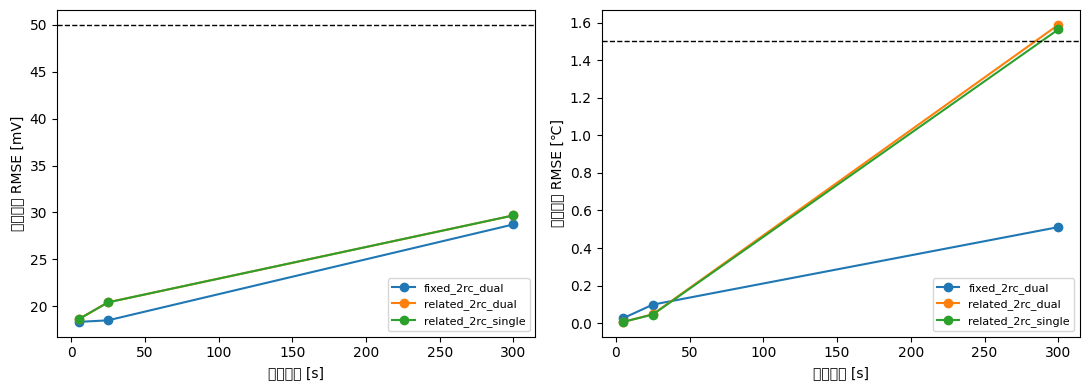

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, group in holdout.groupby("variant"):
    axes[0].plot(group.horizon_s, group.voltage_rmse_mv_mean, marker="o", label=name)
    axes[1].plot(group.horizon_s, group.temperature_rmse_c_mean, marker="o", label=name)
axes[0].axhline(50, color="black", linestyle="--", linewidth=1)
axes[1].axhline(1.5, color="black", linestyle="--", linewidth=1)
axes[0].set(xlabel="预测时域 [s]", ylabel="平均电压 RMSE [mV]")
axes[1].set(xlabel="预测时域 [s]", ylabel="平均温度 RMSE [℃]")
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [4]:
classes = (horizon[horizon.holdout_soc]
           .groupby(["variant", "horizon_s", "voltage_classification"])
           .size().unstack(fill_value=0))
display(classes)
print("温度真实不可行样本数：", int((~horizon.true_temperature_feasible).sum()))

voltage_classification        false_conservative  false_safe  true_feasible  \
variant            horizon_s                                                  
fixed_2rc_dual     5.0                         0           0             15   
                   25.0                        1           0             12   
                   300.0                       0           0              6   
related_2rc_dual   5.0                         0           0             15   
                   25.0                        0           0             13   
                   300.0                       0           3              6   
related_2rc_single 5.0                         0           0             15   
                   25.0                        0           0             13   
                   300.0                       0           3              6   

voltage_classification        true_infeasible  
variant            horizon_s                   
fixed_2rc_dual     5.0                      3  
                   25.0                     5  
                   300.0                   12  
related_2rc_dual   5.0                      3  
                   25.0                     5  
                   300.0                    9  
related_2rc_single 5.0                      3  
                   25.0                     5  
                   300.0                    9

温度真实不可行样本数： 30


固定参数模型在留出 SOC 上没有电压 false-safe，但 300 s 最大电压误差约 52 mV；本批样本没有真实过温阳性。因此“通过筛查”不等于完整 MPC 域已得到验证。相关参数模型在 300 s 出现 3 个电压 false-safe；其独立热结构拟合很好，而耦合预测明显变差，问题应定位到当前电热耦合辨识/热源传播实现。

## 3. 单温度与双节点热结构

In [5]:
thermal_holdout = (thermal[thermal.holdout_soc]
                   .groupby("thermal_structure")[["rmse_c", "maximum_absolute_error_c"]]
                   .mean().sort_values("rmse_c"))
display(thermal_holdout.style.format("{:.4f}"))

,rmse_c,maximum_absolute_error_c
thermal_structure,,
temperature_related_single,0.0061,0.0126
temperature_related_dual,0.0219,0.0447
fixed_dual,1.7222,2.4739


DFN 数据只给出体积平均温度，没有独立核心/表面温度真值。因而这里能比较平均温度预测，不能证明双节点内部状态分别正确；单温度结构误差较小也不能单独证明它在约束控制中更可靠。

## 4. 2R-B：控制律局部单值性

对每个输入集合标准化后取 25 个近邻，估计

\[
\operatorname{Var}(I_k^\star\mid\phi_k).
\]

门槛为平均局部标准差不超过 0.25 A，最近邻标签差 P95 不超过 0.50 A。该方法是数据邻域诊断，不是解析条件分布证明。

In [6]:
cols = ["feature_set", "mean_local_standard_deviation_a",
        "nearest_neighbor_label_difference_p95_a",
        "variance_reduction_from_current_dnn_5_fraction",
        "significant_reduction_vs_current_dnn"]
display(state[cols].style.format({
    "mean_local_standard_deviation_a": "{:.3f}",
    "nearest_neighbor_label_difference_p95_a": "{:.3f}",
    "variance_reduction_from_current_dnn_5_fraction": "{:.1%}"
}))

,feature_set,mean_local_standard_deviation_a,nearest_neighbor_label_difference_p95_a,variance_reduction_from_current_dnn_5_fraction,significant_reduction_vs_current_dnn
0,electrothermal_4,0.850,2.000,-167.3%,False
1,current_dnn_5_plus_previous_current,0.502,1.021,0.0%,False
2,plus_thermal_split,0.494,1.636,-2.6%,False
3,plus_control_block_phase,0.588,1.240,-23.6%,False
4,plus_mpc_mode,0.530,1.282,-12.8%,False
5,plus_previous_plan_summary,0.413,0.745,37.6%,True
6,plus_target_cap_state,0.502,1.021,0.0%,False
7,all_online_or_diagnostic_variables,0.496,0.826,12.3%,False


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32516\2586592905.py:5: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  ax.invert_yaxis(); ax.legend(); plt.tight_layout(); plt.show()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32516\2586592905.py:5: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  ax.invert_yaxis(); ax.legend(); plt.tight_layout(); plt.show()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32516\2586592905.py:5: UserWarning: Glyph 23616 (\N{CJK UNIFIED IDEOGRAPH-5C40}) missing from font(s) DejaVu Sans.
  ax.invert_yaxis(); ax.legend(); plt.tight_layout(); plt.show()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32516\2586592905.py:5: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from font(s) DejaVu Sans.
  ax.invert_yaxis(); ax.legend(); plt.tight_layout(); plt.show()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32516\2586592905.py:5: UserWarning: Glyph 26631 (\N{CJK

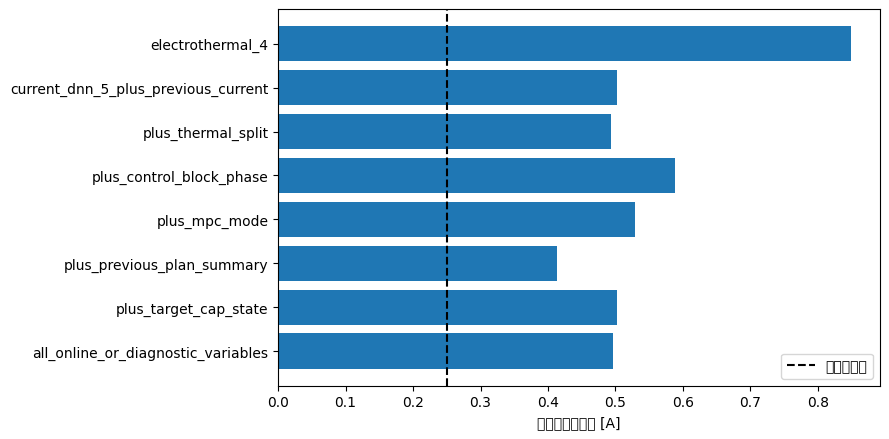

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(state.feature_set, state.mean_local_standard_deviation_a)
ax.axvline(0.25, color="black", linestyle="--", label="单值性门槛")
ax.set(xlabel="平均局部标准差 [A]")
ax.invert_yaxis(); ax.legend(); plt.tight_layout(); plt.show()

上一最优序列摘要带来 37.6% 的平均局部方差下降，是唯一超过 20% 判据的候选变量；但扩充后仍为 0.413 A / 0.745 A，未通过两项门槛。控制相位和事后 MPC 模式没有稳定改善，且存在维数增加引起的近邻稀疏效应，不能据此认定它们无关。

## 5. 回放可信度与变量可用性

In [8]:
display(availability)
replay = metrics["state_audit"]["replay"]
display(pd.DataFrame([{
    "严格逐点成功": replay["exact_success"],
    "差异P95 [A]": replay["p95_replay_current_difference_a"],
    ">0.01 A比例": replay["large_difference_fraction"],
    "统计诊断可用": replay["memory_summary_usable"],
    "最大差异 [A]": replay["maximum_replay_current_difference_a"],
}]).style.format({"差异P95 [A]": "{:.6f}", ">0.01 A比例": "{:.2%}", "最大差异 [A]": "{:.3f}"}))
assert not replay["exact_success"] and replay["memory_summary_usable"]

,candidate,status,detail
0,I_k_minus_1,available,state_previous_current_a 已在当前五状态 DNN 中
1,control_block_phase,recoverable_proxy,使用 step_index mod control_block_steps；滚动 MPC 每...
2,ambient_temperature,constant_not_identifiable,Phase 6R 教师数据全部为 25 ℃
3,current_mpc_mode,diagnostic_only,由求解后的活跃约束定义，不能直接作为求解前在线输入
4,previous_optimal_sequence_summary,replayed_approximate,记录上一控制块首项/均值/末项；CSV 状态重启在少数切换点不能严格复现
5,identifiable_parameters,constant_not_identifiable,Phase 6R 使用同一组固定 2RC/热参数
6,target_cap_state,replayed_diagnostic,由预测终端 SOC 是否接近目标构造


,严格逐点成功,差异P95 [A],>0.01 A比例,统计诊断可用,最大差异 [A]
0,False,0.000301,1.63%,True,0.224


CSV 状态舍入和 SLSQP 在约束切换点的局部解导致严格重放失败；P95 差异为约 0.30 mA，超过 10 mA 的比例为 1.63%。所以历史序列摘要只可用于本轮统计诊断，下一批教师数据必须在生成时直接记录，不能由事后重放替代。

## 6. 阶段决策

1. **暂不训练新 ANN，也不进入 A1。**
2. 新教师数据应原生记录上一可行/最优序列摘要，并做相同邻域方差审计；若仍高，再考虑更完整的控制记忆或模式分区。
3. 修正相关参数模型的电热耦合后，复核 15 ℃、2 C、300 s 与 3 个电压 false-safe；补充可产生真实过温阳性的受控测试，才能评价温度约束分类。
4. 环境温度和可辨识参数在当前 Phase 6R 数据中为常量，其必要性不可识别；需要跨温度/参数数据后再审计。

这将 Chen2020 的优先问题从“基础 DNN 管线错误”进一步收敛为：**控制记忆缺失导致的标签非单值性，以及降阶模型在长时域/约束边界的电热耦合误差。**